# Fitting on Chip Inductors (1-40 GHz)

This tutorial demonstrates how more complex models can be generated and fitted onto s-parameter data. For this tutorial we will use data from an electromagnetic simulation of this on-chip inductor typical in MMICs or RFICs.

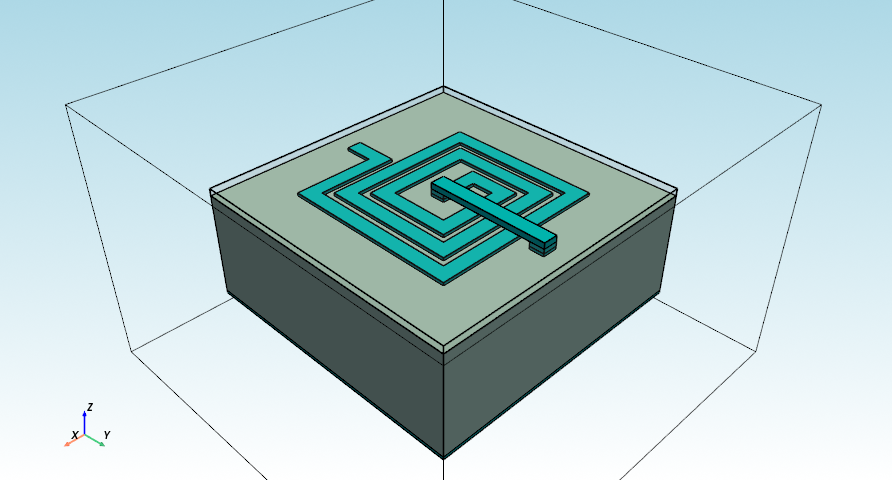


## The Equivalent Circuit

To accurately capture the complex parasitic behaviour of this model we will utilize the equivalent circuit outlined in the paper:
_"N-π Equivalent Circuit for Si CMOS on-Chip Inductor Modeling"_ [IEEE Link](https://ieeexplore.ieee.org/document/4534622). 

The equivalent circuit is built from repeated π sections, where each section models one portion of the spiral trace and its surrounding parasitics. Using multiple sections improves accuracy at higher frequencies, where the distributed nature of the structure becomes significant.

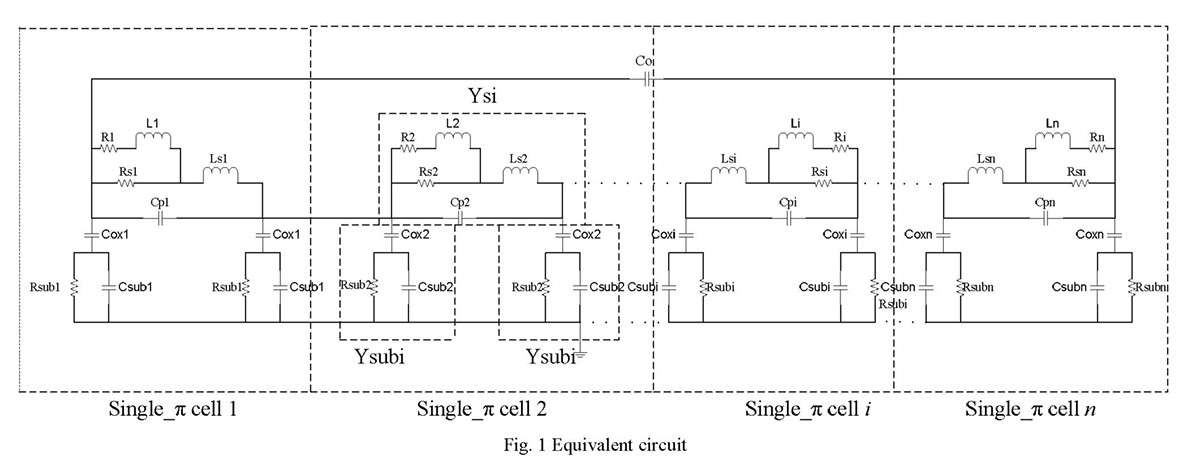

The model is constructed in two stages.
In the first stage, a single π cell is defined to match the schematic above. Each passive element is instantiated individually; for example `L1_model = pmrf.models.Inductor(L=L, name="L")` — and the topology is then encoded as a list of node connections passed to pmrf.models.Circuit. This declarative connection syntax makes the mapping between schematic and code straightforward to verify.

In [1]:
import pmrf


def single_pi_cell(R, L, Rs, Ls, Cp, Cox1, Cox2, Rsub1, Csub1, Rsub2, Csub2, **kwargs):
    L1_model = pmrf.models.Inductor(L=L, name="L")
    Ls1_model = pmrf.models.Inductor(L=Ls, name="Ls")

    Cp1_model = pmrf.models.Capacitor(C=Cp, name="Cp")
    Cox1_model = pmrf.models.Capacitor(C=Cox1, name="Cox1")
    Cox2_model = pmrf.models.Capacitor(C=Cox2, name="Cox2")

    Csub1_model = pmrf.models.Capacitor(C=Csub1, name="Csub1")
    Csub2_model = pmrf.models.Capacitor(C=Csub2, name="Csub2")

    R1_model = pmrf.models.Resistor(R=R, name="R")
    Rs1_model = pmrf.models.Resistor(R=Rs, name="Rs")
    Rsub1_model = pmrf.models.Resistor(R=Rsub1, name="Rsub1")
    Rsub2_model = pmrf.models.Resistor(R=Rsub2, name="Rsub2")

    port1, port2 = pmrf.models.Port(), pmrf.models.Port()
    ground = pmrf.models.Ground()

    connections = [
        [(port1, 0), (Cox1_model, 1), (Cp1_model, 0), (R1_model, 0), (Rs1_model, 0)],
        [(R1_model, 1), (L1_model, 0)],
        [(L1_model, 1), (Rs1_model, 1), (Ls1_model, 0)],
        [(port2, 0), (Cox2_model, 1), (Cp1_model, 1), (Ls1_model, 1)],
        [(Cox1_model, 0), (Rsub1_model, 1), (Csub1_model, 1)],
        [(Cox2_model, 0), (Rsub2_model, 1), (Csub2_model, 1)],
        [
            (ground, 0),
            (Csub1_model, 0),
            (Csub2_model, 0),
            (Rsub1_model, 0),
            (Rsub2_model, 0),
        ],
    ]

    inductor_model = pmrf.models.Circuit(connections, **kwargs)

    return inductor_model


In the second stage, the single-cell definition is reused inside a loop to build an N-section cascade. Each cell is assigned a unique name (e.g. cell0, cell1) so its parameters can be tracked and inspected independently after fitting. An input-output capacitor C0 is then added in parallel across the full cascade to account for direct port-to-port coupling, completing the model.

In [2]:
def multi_pi_cell(num, R, L, Rs, Ls, Cp, Cox1, Cox2, Rsub1, Csub1, Rsub2, Csub2, C0):
    if num <= 1:
        return single_pi_cell(R, L, Rs, Ls, Cp, Cox1, Cox2, Rsub1, Csub1, Rsub2, Csub2)

    models = []
    for i in range(num):
        models.append(
            single_pi_cell(R, L, Rs, Ls, Cp, Cox1, Cox2, Rsub1, Csub1, Rsub2, Csub2, name=f"cell{i}")
        )

    port1, port2 = pmrf.models.Port(), pmrf.models.Port()
    cascade = pmrf.models.Cascade(models)

    C0_model = pmrf.models.Capacitor(C=C0)

    connections = [
        [(port1, 0), (cascade, 0), (C0_model, 0)],
        [(port2, 0), (cascade, 1), (C0_model, 1)],
    ]

    return pmrf.models.Circuit(connections)


## Optimising the Model
With the circuit topology defined, the next step is to extract parameters via optimisation. The pmrf.Bounded wrapper tells the optimizer the physically reasonable range for each parameter, along with a starting value and a scale factor that helps condition the problem numerically. Choosing sensible bounds is important: too narrow and the optimizer may miss the true solution; too wide and convergence becomes slow and unreliable.

In [3]:
import pmrf

# Define model (N-Pi Equivalent Circuit for Si CMOS on-Chip Inductor Modeling)
inductor_model = multi_pi_cell(
    num=2,
    R=pmrf.Bounded(-1.0, 1000.0, value=0.0, scale=1.0),
    L=pmrf.Bounded(0.0, 5.0, value=0.5, scale=1e-9),
    Rs=pmrf.Bounded(-1.0, 1000.0, value=0.0, scale=1.0),
    Ls=pmrf.Bounded(0.0, 5.0, value=0.5, scale=1e-9),
    Cp=pmrf.Bounded(-1.0, 5.0, value=0.0, scale=1e-12),
    Cox1=pmrf.Bounded(-1.0, 5.0, value=0.0, scale=1e-12),
    Cox2=pmrf.Bounded(-1.0, 5.0, value=0.0, scale=1e-12),
    Rsub1=pmrf.Bounded(-1.0, 1000.0, value=0.0, scale=1.0),
    Csub1=pmrf.Bounded(-1.0, 5.0, value=0.0, scale=1e-12),
    Rsub2=pmrf.Bounded(-1.0, 1000.0, value=0.0, scale=1.0),
    Csub2=pmrf.Bounded(-1.0, 5.0, value=0.0, scale=1e-12),
    C0=pmrf.Bounded(-1.0, 5.0, value=0.0, scale=1e-12),
)

The fit runs using SciPy's optimizer by default, minimizing the difference between the modeled and measured S-parameters across all frequencies simultaneously. Convergence typically takes a few hundred iterations. Once complete, inductor_fit holds both the optimized parameter values and the fitted network, ready for post-processing.

In [ ]:
import skrf

# Load Data
simulated_params = skrf.Network("./Data/On chip inductor.s2p")

# Fit
inductor_fit = pmrf.fitting.fit(inductor_model, simulated_params)

SciPy (default):   0%|          | 0/1024 [00:00<?, ?it/s]

## Reviewing the Fit
### S Parameters
Now that you have got a fitted model you can show the results to compare the fit to the truth, showing excellent correlation.

Text(0.5, 1.0, 'Smith Chart - Model vs Simulated')

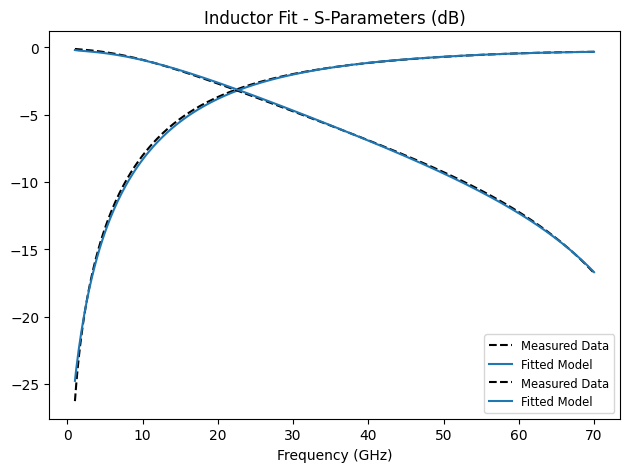

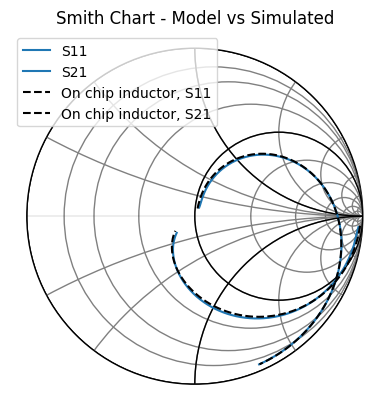

In [5]:
import matplotlib.pyplot as plt

# Plot 1 - S-parameter dB
fig1, ax1 = plt.subplots()
inductor_fit.plot_s_db(m=0, n=0, ax=ax1)
inductor_fit.plot_s_db(m=1, n=0, ax=ax1)
ax1.set_title("Inductor Fit - S-Parameters (dB)")

# Plot 2 - Smith Chart
fig2, ax2 = plt.subplots()
freq = pmrf.Frequency(1, 70, 1001, "GHz")
skrf_model = inductor_fit.model.to_skrf(frequency=freq)
skrf_model.plot_s_smith(m=0, n=0, ax=ax2, color="tab:blue")
skrf_model.plot_s_smith(m=1, n=0, ax=ax2, color="tab:blue")
simulated_params.plot_s_smith(m=0, n=0, ax=ax2, color="black", linestyle="--")
simulated_params.plot_s_smith(m=1, n=0, ax=ax2, color="black", linestyle="--")
ax2.set_title("Smith Chart - Model vs Simulated")

### Inductance and Q Factor
You can also then print out the Inductance and Q factor by defining a function to plot.

[1.0000e+09 1.0690e+09 1.1380e+09 ... 6.9862e+10 6.9931e+10 7.0000e+10]


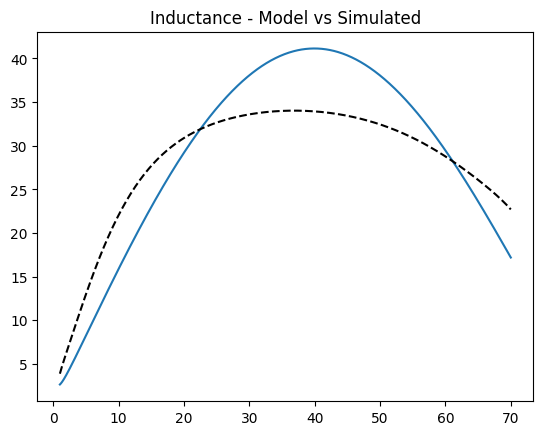

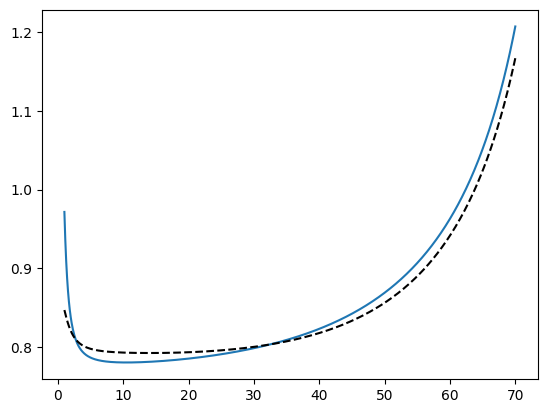

In [9]:
import jax.numpy as jnp

freq = pmrf.Frequency(1, 70, 1001, "GHz")
model = inductor_fit.model.s(freq)

def Q_Factor(s_params):
    y = pmrf.rf.s2y(s_params)
    z = 1 / y[:, 0, 1]
    z_real = jnp.real(z)
    z_imag = jnp.imag(z)
    return z_imag / z_real

def inductance(s_params, freqs, z0=50.0):
    y = pmrf.rf.s2y(s_params)
    z = -1 / y[:, 0, 1]
    z_imag = jnp.imag(z)
    L = z_imag / (freqs * 2 * jnp.pi)
    
    return L * 1e9  # convert to nH

fig1, ax1 = plt.subplots()
ax1.plot(freq.f / 1e9, Q_Factor(model), color="tab:blue")
ax1.plot(simulated_params.f / 1e9, Q_Factor(simulated_params.s), color="black", linestyle="--")
ax1.set_title("Q_Factor - Model vs Simulated")

fig1, ax2 = plt.subplots()
ax2.plot(freq.f / 1e9, inductance(model, freq.f), color="tab:blue")
ax2.plot(simulated_params.f / 1e9, inductance(simulated_params.s, simulated_params.f), color="black", linestyle="--")
ax1.set_title("Inductance - Model vs Simulated")

print(freq.f)

You can then print out the final fitted parameters.

In [10]:
import pprint

print("Final Fitted Parameters:")
pprint.pprint(inductor_fit.model.named_params())

Final Fitted Parameters:
{'cell0_Cox1.C': 1.739110392039267e-14,
 'cell0_Cox2.C': 7.819493540128564e-15,
 'cell0_Cp.C': -1.331702421532388e-14,
 'cell0_Csub1.C': 0.0,
 'cell0_Csub2.C': -2.0007962886481321e-19,
 'cell0_L.L': 4.845355822793674e-10,
 'cell0_Ls.L': 6.075021995200489e-10,
 'cell0_R.R': 0.0028747098234427337,
 'cell0_Rs.R': 1.149292827814378,
 'cell0_Rsub1.R': 0.15604532510702374,
 'cell0_Rsub2.R': 0.02265116791869315,
 'cell1_Cox1.C': 7.80739364464722e-15,
 'cell1_Cox2.C': 8.35547656783997e-15,
 'cell1_Cp.C': 1.6531793754349432e-14,
 'cell1_Csub1.C': 0.0,
 'cell1_Csub2.C': -3.7169505204937e-17,
 'cell1_L.L': 4.4959748425733356e-10,
 'cell1_Ls.L': 1.6858158997486263e-10,
 'cell1_R.R': 0.005574301115401914,
 'cell1_Rs.R': 1.8546529132534322,
 'cell1_Rsub1.R': 0.022647468943546967,
 'cell1_Rsub2.R': 0.06770755985292931,
 'circuit[2].C': 1.0902359492053204e-14}
